In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Checking Varaince Scheduler

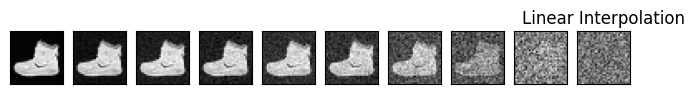

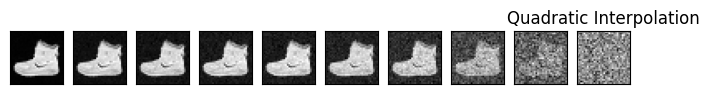

In [ ]:
import torch

import matplotlib.pyplot as plt

from main import load_data
from models import VarianceScheduler


# define the configurations of the Variance Scheduler
beta1 = 0.0001
beta2 = 0.02
num_steps = 1000
interpolation = 'linear'

# sample data
dataset = load_data()
sample_image = dataset[0][0].unsqueeze(0)

time_steps = torch.tensor([0, 10, 20, 30, 40, 50, 100, 200, 500, 999], dtype=torch.long)
sample_image = sample_image.repeat(10, 1, 1, 1)

# define the variance scheduler with linear interpolation
var_scheduler = VarianceScheduler(beta_start=beta1, beta_end=beta2, num_steps=num_steps, interpolation=interpolation)

noisy_samples, _ = var_scheduler.add_noise(sample_image, time_steps)

fig, ax = plt.subplots(1, 10)
fig.set_size_inches(8, 2)
for i in range(10):
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].imshow(noisy_samples[i, 0].numpy(), cmap='gray')

plt.title('Linear Interpolation')
plt.show()


# define the variance scheduler with quadratic interpolation
interpolation = 'quadratic'
var_scheduler = VarianceScheduler(beta_start=beta1, beta_end=beta2, num_steps=num_steps, interpolation=interpolation)

noisy_samples, _ = var_scheduler.add_noise(sample_image, time_steps)

fig, ax = plt.subplots(1, 10)
fig.set_size_inches(8, 2)
for i in range(10):
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].imshow(noisy_samples[i, 0].numpy(), cmap='gray')

plt.title('Quadratic Interpolation')
plt.show()

## Training DDPM

In [ ]:
!python main.py --model ddpm --mode train



	 Training DDPM ...
  0% 0/30 [00:00<?, ?it/s]Epoch: 0 - Loss: 0.227 (78.23 sec)
  3% 1/30 [01:23<40:15, 83.28s/it]Epoch: 1 - Loss: 0.149 (79.41 sec)
  7% 2/30 [02:47<39:07, 83.83s/it]Epoch: 2 - Loss: 0.136 (79.47 sec)
 10% 3/30 [04:11<37:48, 84.04s/it]Epoch: 3 - Loss: 0.128 (79.58 sec)
 13% 4/30 [05:36<36:28, 84.17s/it]Epoch: 4 - Loss: 0.124 (79.43 sec)
 17% 5/30 [07:00<35:06, 84.24s/it]Epoch: 5 - Loss: 0.120 (79.61 sec)
 20% 6/30 [08:24<33:43, 84.30s/it]Epoch: 6 - Loss: 0.118 (79.41 sec)
 23% 7/30 [09:49<32:18, 84.27s/it]Epoch: 7 - Loss: 0.115 (79.46 sec)
 27% 8/30 [11:13<30:53, 84.27s/it]Epoch: 8 - Loss: 0.113 (79.37 sec)
 30% 9/30 [12:37<29:28, 84.24s/it]Epoch: 9 - Loss: 0.111 (79.33 sec)
 33% 10/30 [14:01<28:04, 84.21s/it]Epoch: 10 - Loss: 0.110 (79.14 sec)
 37% 11/30 [15:25<26:38, 84.13s/it]Epoch: 11 - Loss: 0.109 (79.08 sec)
 40% 12/30 [16:49<25:13, 84.06s/it]Epoch: 12 - Loss: 0.107 (79.32 sec)
 43% 13/30 [18:13<23:50, 84.12s/it]Epoch: 13 - Loss: 0.105 (79.33 sec)
 47% 14/30 [

## DDPM Image Generation

saves the results in your project directory as "DDPM_generated_samples.png"

In [ ]:
!python main.py --model ddpm --mode generate



	 Generating images using DDPM ...


	 Generated images saved!
Accuracy: 96.00%	 Score: 1.00


## Trainin DDIM

In [ ]:
!python main.py --model ddim --mode train



	 Training DDIM ...
  0% 0/10 [00:00<?, ?it/s]Epoch: 0 - Loss: 0.095 (80.18 sec)
 10% 1/10 [01:25<12:45, 85.10s/it]Epoch: 1 - Loss: 0.094 (78.95 sec)
 20% 2/10 [02:48<11:14, 84.28s/it]Epoch: 2 - Loss: 0.093 (78.84 sec)
 30% 3/10 [04:12<09:47, 83.98s/it]Epoch: 3 - Loss: 0.092 (78.80 sec)
 40% 4/10 [05:36<08:22, 83.83s/it]Epoch: 4 - Loss: 0.093 (78.79 sec)
 50% 5/10 [06:59<06:58, 83.78s/it]Epoch: 5 - Loss: 0.092 (78.89 sec)
 60% 6/10 [08:23<05:34, 83.74s/it]Epoch: 6 - Loss: 0.093 (79.01 sec)
 70% 7/10 [09:47<04:11, 83.76s/it]Epoch: 7 - Loss: 0.092 (78.95 sec)
 80% 8/10 [11:10<02:47, 83.76s/it]Epoch: 8 - Loss: 0.091 (78.81 sec)
 90% 9/10 [12:34<01:23, 83.70s/it]Epoch: 9 - Loss: 0.092 (78.91 sec)
100% 10/10 [13:58<00:00, 83.82s/it]


## DDIM Image Generation

saves the results in your project directory as "DDIM_generated_samples.png"

In [ ]:
!python main.py --model ddim --mode generate



	 Generating images using DDIM ...


	 Generated images saved!
Accuracy: 90.00%	 Score: 1.00


## Training VAE

In [ ]:
!python main.py --model vae --mode train



	 Training VAE ...
  0% 0/30 [00:00<?, ?it/s]Epoch: 0 - Recon Loss: 38576.731 - KL Loss: 1875.824 - Loss: 40452.555 (65.73sec)
  3% 1/30 [01:06<31:59, 66.20s/it]Epoch: 1 - Recon Loss: 30685.572 - KL Loss: 1760.939 - Loss: 32446.511 (64.27sec)
  7% 2/30 [02:10<30:21, 65.06s/it]Epoch: 2 - Recon Loss: 29892.434 - KL Loss: 1728.684 - Loss: 31621.118 (64.37sec)
 10% 3/30 [03:15<29:11, 64.87s/it]Epoch: 3 - Recon Loss: 29508.224 - KL Loss: 1715.329 - Loss: 31223.553 (64.29sec)
 13% 4/30 [04:19<28:00, 64.64s/it]Epoch: 4 - Recon Loss: 29221.532 - KL Loss: 1709.872 - Loss: 30931.404 (64.40sec)
 17% 5/30 [05:24<26:56, 64.66s/it]Epoch: 5 - Recon Loss: 29001.265 - KL Loss: 1718.618 - Loss: 30719.882 (64.43sec)
 20% 6/30 [06:28<25:49, 64.58s/it]Epoch: 6 - Recon Loss: 28841.130 - KL Loss: 1724.350 - Loss: 30565.480 (64.37sec)
 23% 7/30 [07:33<24:45, 64.60s/it]Epoch: 7 - Recon Loss: 28735.462 - KL Loss: 1730.626 - Loss: 30466.087 (64.39sec)
 27% 8/30 [08:37<23:39, 64.53s/it]Epoch: 8 - Recon Loss: 28

## VAE Image Generation

saves the results in your project directory as "VAE_generated_samples.png"

In [ ]:
!python main.py --model vae --mode generate



	 Generating images using VAE ...


	 Generated images saved!
Accuracy: 88.00%	 Score: 1.00


## Training LDDPM

In [ ]:
!python main.py --model lddpm --mode train



	 Training LDDPM ...
  0% 0/50 [00:00<?, ?it/s]torch.Size([128, 128])
torch.Size([128])
  0% 0/50 [00:00<?, ?it/s]
Traceback (most recent call last):
  File "/content/drive/MyDrive/a5/main.py", line 88, in <module>
    trainer(model, train_loader, 
  File "/content/drive/MyDrive/a5/trainers.py", line 155, in train_lddpm
    loss = diffusion_model(x, label)
  File "/usr/local/lib/python3.10/dist-packages/torch/nn/modules/module.py", line 1736, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/torch/nn/modules/module.py", line 1747, in _call_impl
    return forward_call(*args, **kwargs)
  File "/content/drive/MyDrive/a5/models.py", line 411, in forward
    estimated_noise = self.network(noisy_input, t, label)
  File "/usr/local/lib/python3.10/dist-packages/torch/nn/modules/module.py", line 1736, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/torch/nn/module

## LDDPM Image Generation

saves the results in your project directory as "LDDM_generated_samples.png"

In [ ]:
!python main.py --model lddpm --mode generate